In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import getpass
import os
import random
import re
import tarfile
import time
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.utils as utils
import torchvision.transforms as transforms
import pandas as pd
import seaborn as sns
from collections import Counter
import torchvision.models as models
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm
from IPython.display import clear_output
from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import transforms as T
from torchvision.transforms import v2 as T2
from torchvision.transforms.v2 import functional as F
from torchvision.tv_tensors import BoundingBoxes
from torchvision.tv_tensors import Image as TVImage
from PIL import Image as PILImage

In [ ]:
BASE_DIR = r"C:\Users\sophi\image\iapr2025\images\robo"

TRAIN_ANNOTATIONS_CSV = os.path.join(BASE_DIR, "train_annotations.csv")
VAL_ANNOTATIONS_CSV = os.path.join(BASE_DIR, "valid_annotations.csv")
IMAGE_DIR_TRAIN = os.path.join(BASE_DIR, "train")
IMAGE_DIR_VAL = os.path.join(BASE_DIR, "valid")
TEST_IMAGE_DIR = r'C:\Users\sophi\image\iapr2025\project\images\train_robo_1\test'

BATCH_SIZE = 10
EPOCHS = 3
LEARNING_RATE = 0.001
NUM_CLASSES = 13
INPUT_SIZE = 224

# CSV_PATH = 'C:\Users\sophi\image\iapr2025\chocolate-recognition-ml\dataset_project_iapr2025\train.csv'

grid_size = 7
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
classes = ("Jelly White", "Jelly Milk", "Jelly Black", "Amandina", "Creme brulee", "Triangolo", "Tentation noir",
           "Comtesse", "Noblesse", "Noir authentique", "Passion au lait", "Arabia", "Stracciatella")

In [ ]:
class ChocolateDetectionDataset(Dataset):
    def __init__(self, csv_path, image_dir, classes, image_size = (224,224), transform=None):
        self.df = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.classes = classes
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}
        self.image_size = image_size
        self.transform = transform

        # Group annotations by image
        self.image_data = self.df.groupby('filename')
        self.image_filenames = list(self.image_data.groups.keys())

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        records = self.image_data.get_group(img_name)

        # Load image
        img_path = os.path.join(self.image_dir, img_name)
        image = PILImage.open(img_path).convert("RGB")
        
        boxes = records[['xmin', 'ymin', 'xmax', 'ymax']].values
        boxes = torch.tensor(boxes, dtype=torch.float32)

        # bounding box needs to be a torchvision BoundingBoxes object
        boxes = BoundingBoxes(boxes, format="XYXY", canvas_size=image.size[::-1])  # PIL: (W, H)

        labels = torch.tensor([self.class_to_idx[row["class"]] for _, row in records.iterrows()], dtype=torch.int64)    
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        if self.transform:
            # image, target = self.transform(image, target)
            sample = {"image": image, "target": target}
            sample = self.transform(sample)
            image = sample["image"]
            target = sample["target"]
    
        return image, target


In [ ]:
normalize = T2.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

transform = T2.Compose([
    T2.ToImage(),
    T2.Resize((224,224)),
    T2.ToDtype(torch.float32, scale=True),
    normalize,
])

train_dataset = ChocolateDetectionDataset(
    csv_path=r"C:\Users\sophi\image\iapr2025\project\images\robo\train_annotations.csv",
    image_dir=r"C:\Users\sophi\image\iapr2025\project\images\robo\train",
    classes=classes,
    transform=transform
)

val_dataset = ChocolateDetectionDataset(
    csv_path=r"C:\Users\sophi\image\iapr2025\project\images\robo\valid_annotations.csv",
    image_dir=r"C:\Users\sophi\image\iapr2025\project\images\robo\valid",
    classes=classes,
    transform=transform
)

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)


In [62]:
# Visualization of images
def plot_images_from_dataset(images, targets):
    batch_size = len(images)
    fig = plt.figure(figsize=(12, 12))
    for idx in range(batch_size):
        img = images[idx].numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # unnormalize
        img = np.clip(img, 0, 1)

        ax = fig.add_subplot(3, int(np.ceil(batch_size / 3)), idx + 1)
        ax.imshow(img)
        ax.axis('off')

        boxes = targets[idx]['boxes']
        labels = targets[idx]['labels']

        for box, label in zip(boxes, labels):
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor='red', linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, classes[label], color='red', fontsize=8, weight='bold')

    plt.tight_layout()
    plt.show()

# Load one batch
dataiter = iter(train_dataloader)
images, targets = next(dataiter)

# Visualize
# plot_images_from_dataset(images, targets)


Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>


Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>


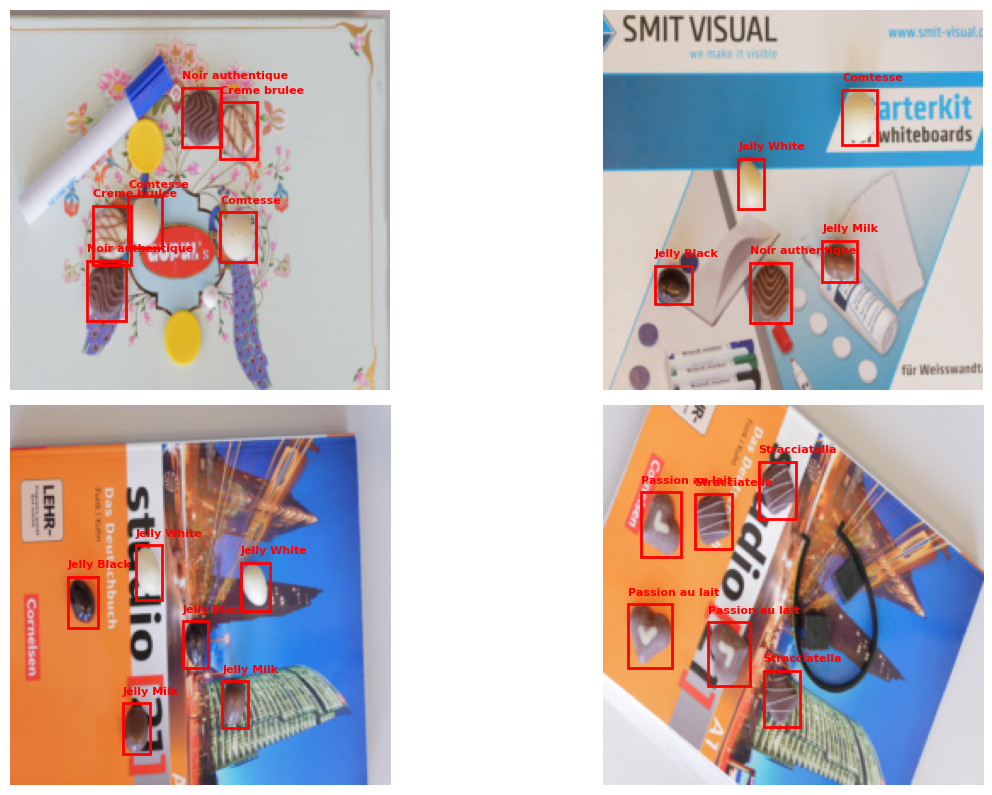

In [63]:
plot_images_from_dataset(*next(iter(train_dataloader)))

In [64]:
def f1(preds, target):
    return f1_score(target, preds, average='macro')

def acc(preds, target):
    return accuracy_score(target, preds)

In [65]:
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        import torchvision

        NUM_CLASSES = 14  # 13 classes + background

        self.model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=False)
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)

        # to reduce the computational complexity we reduce the size and number of hidden layers
        # self.model.classifier = nn.Sequential(
        #     nn.Dropout(p=0.35, inplace=False),
        #     nn.Linear(in_features=9216, out_features=128, bias=True),
        #     nn.ReLU(inplace=True),
        #     nn.Linear(in_features=128, out_features=10, bias=True)
        # )

    def freeze_feature_layers(self):
        # freeze the feature extraction part
        for param in self.model.backbone.body.parameters():
            param.requires_grad = False

    def forward(self, images, targets=None):
        if self.training:
            return self.model(images, targets)  # returns losses during training
        else:
            return self.model(images)

In [34]:
def train_epoch(model, optimizer, train_loader, device):
    model.train()
    running_loss = 0.0

    for images, targets in tqdm(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        running_loss += losses.item()

    return running_loss / len(train_loader)


In [35]:
def evaluate(model, dataloader, device):
    model.eval()
    total_images = 0
    detections = []
    total_loss = 0.0
    count = 0

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            # First: compute loss (this only works if targets are provided)
            try:
                loss_dict = model(images, targets)
                if isinstance(loss_dict, dict):
                    losses = sum(loss for loss in loss_dict.values())
                    total_loss += losses.item()
                    count += 1
            except:
                print("Warning: model didn't return loss dictionary during evaluation.")

            # Second: get predictions
            outputs = model(images)

            for i in range(len(images)):
                detections.append({
                    'pred_boxes': outputs[i]['boxes'].cpu(),
                    'pred_labels': outputs[i]['labels'].cpu(),
                    'gt_boxes': targets[i]['boxes'].cpu(),
                    'gt_labels': targets[i]['labels'].cpu(),
                })

            total_images += len(images)

    avg_loss = total_loss / count if count > 0 else 0.0
    print(f"Evaluated {total_images} images.")
    return avg_loss


In [36]:
def plot_training(train_loss, test_loss, metrics_names, train_metrics_logs, test_metrics_logs):
    fig, ax = plt.subplots(1, len(metrics_names) + 1, figsize=((len(metrics_names) + 1) * 5, 5))

    ax[0].plot(train_loss, c='blue', label='train')
    ax[0].plot(test_loss, c='orange', label='test')
    ax[0].set_title('Loss')
    ax[0].set_xlabel('epoch')
    ax[0].legend()

    for i in range(len(metrics_names)):
        ax[i + 1].plot(train_metrics_logs[i], c='blue', label='train')
        ax[i + 1].plot(test_metrics_logs[i], c='orange', label='test')
        ax[i + 1].set_title(metrics_names[i])
        ax[i + 1].set_xlabel('epoch')
        ax[i + 1].legend()

    plt.show()

def update_metrics_log(metrics_names, metrics_log, new_metrics_dict):
    '''
    - metrics_names: the keys/names of the logged metrics
    - metrics_log: existing metrics log that will be updated
    - new_metrics_dict: epoch_metrics output from train_epoch and evaluate functions
    '''
    for i in range(len(metrics_names)):
        curr_metric_name = metrics_names[i]
        metrics_log[i].append(new_metrics_dict[curr_metric_name])
    return metrics_log

In [66]:
for batch in train_dataloader:
    print(type(batch), len(batch))
    print(type(batch[0]), type(batch[1]))
    print(batch[1][0])
    break

Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
<class 'tuple'> 2
<class 'list'> <class 'list'>
{'boxes': BoundingBoxes([[ 31.3600, 103.0400,  54.5067, 139.1600],
               [108.2667,  72.2400, 130.6667, 107.2400],
               [ 72.8000,  79.5200,  92.7733, 108.6400],
               [143.7333, 123.2000, 164.6400, 154.5600],
               [ 86.2400, 119.2800, 112.3733, 157.3600]], format=BoundingBoxFormat.XYXY, canvas_size=(224, 224)), 'labels': tensor([ 4,  4, 11, 11, 10]), 'image_id': tensor([34])}


In [67]:
# Fetch a single batch from the train_dataloader
images, targets = next(iter(train_dataloader))

# Check the type of `images`
print("Type of images:", type(images))
print("Number of images in batch:", len(images))
print("Type of one image:", type(images[0]))
print("Image shape:", images[0].shape)

# Check the type and keys of targets
print("Type of targets:", type(targets))
print("Number of targets in batch:", len(targets))
print("Type of one target:", type(targets[0]))
print("Keys in one target dict:", targets[0].keys())
print("Example labels:", targets[0]['labels'])
print("Example boxes:", targets[0]['boxes'])

Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Type of images: <class 'list'>
Number of images in batch: 4
Type of one image: <class 'torchvision.tv_tensors._image.Image'>
Image shape: torch.Size([3, 224, 224])
Type of targets: <class 'list'>
Number of targets in batch: 4
Type of one target: <class 'dict'>
Keys in one target dict: dict_keys(['boxes', 'labels', 'image_id'])
Example labels: tensor([ 3,  4,  2, 12, 11, 11])
Example boxes: BoundingBoxes([[ 78.7733,  62.7200,  98.5600, 112.5600],
               [ 60.8533, 129.3600,  84.1867, 165.2000],
               [111.6267, 174.1600, 131.6000, 197.4000],
               [159.7867,  54.3200, 181.0667,  88.2000],
               [154.5600, 145.6000, 174.3467, 175.0000],
               [173.9733, 152.8800, 192.4533, 182.5600]], format=BoundingBoxFormat.XYXY, canvas_size=(224, 224))


In [ ]:
def train_cycle(model, optimizer, train_loader, val_loader, n_epochs, device):
    train_loss_log, val_loss_log = [], []

    for epoch in range(n_epochs):
        print(f"\nEpoch {epoch+1}/{n_epochs}")
        
        train_loss = train_epoch(model, optimizer, train_loader, device)
        val_loss = evaluate(model, val_loader, device)

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        train_loss_log.append(train_loss)
        val_loss_log.append(val_loss)

    return train_loss_log, val_loss_log


In [16]:
torch.manual_seed(42)

model = Net()
model.freeze_feature_layers()

learning_rate = 0.0001

criterion = nn.CrossEntropyLoss()
metrics = {'ACC': acc, 'F1-weighted': f1}
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

N_EPOCHS = 1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
criterion.to(device)

# train_metrics_log_base, test_metrics_log_base = train_cycle(model, optimizer, criterion, metrics, train_dataloader, val_dataloader, N_EPOCHS, device)
train_cycle(model, optimizer, train_dataloader, val_dataloader, N_EPOCHS, device)

# save model
results_models_dir = 'models/'
if not os.path.exists(results_models_dir):
    os.mkdir(results_models_dir)
torch.save(model.state_dict(), results_models_dir + 'base_model_epoch60.pth')

Evaluating: 100%|██████████| 6/6 [00:10<00:00,  1.77s/it]

Evaluated 21 images.
Train Loss: 173.8034 | Val Loss: 0.0000


In [17]:
import torch
import os
import pandas as pd
from PIL import Image
from torchvision import transforms

def predict_and_create_submission(submission_template_path, output_csv_path, model_weights_path, classes, device, transform, TEST_IMAGE_DIR):
    # Load model
    model = Net()  # Ensure Net class is defined before this
    model.load_state_dict(torch.load(model_weights_path, map_location=device))
    model.to(device)
    model.eval()

    # Prepare submission
    submission_df = pd.read_csv(submission_template_path)
    image_ids = submission_df['id'].tolist()
    filenames = ['L' + str(i) + '.JPG' for i in image_ids]
    results = []

    for img_id, fname in zip(image_ids, filenames):
        img_path = os.path.join(TEST_IMAGE_DIR, fname)
        if not os.path.exists(img_path):
            print(f"Missing image: {img_path}")
            results.append([img_id] + [0] * len(classes))
            continue

        image = Image.open(img_path).convert('RGB')
        image_tensor = transform(image).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(image_tensor)

        # outputs is a list of predictions
        output = outputs[0]
        labels = output['labels'].cpu().tolist()

        # Count class occurrences
        counts = [0] * len(classes)
        for label in labels:
            if 0 <= label < len(classes):
                counts[label] += 1

        results.append([img_id] + counts)

    # Save to CSV
    result_df = pd.DataFrame(results, columns=['id'] + list(classes))
    result_df.to_csv(output_csv_path, index=False)
    print(f"Submission saved to {output_csv_path}")



In [18]:
sample_submission_path = 'C:/Users/sophi/image/iapr2025/chocolate-recognition-ml/dataset_project_iapr2025/sample_submission.csv'
output_submission_path = 'C:/Users/sophi/image/iapr2025/project/prediction/ann_submission_epoch60.csv'
# predict_and_create_submission(model, sample_submission_path, output_submission_path)
predict_and_create_submission(
    sample_submission_path,
    output_submission_path,
    model_weights_path='C:/Users/sophi/image/iapr2025/project/models/base_model_epoch60.pth',
    classes=classes,  # List of class names
    device=device,
    transform=transform,  # Your preprocessing pipeline
    TEST_IMAGE_DIR=TEST_IMAGE_DIR
)

Submission saved to C:/Users/sophi/image/iapr2025/project/prediction/ann_submission_epoch60.csv


Augmentation

In [68]:
# Define new transform (image + bounding boxes support)
augmented_transform_train = T2.Compose([
    T2.ToImage(),  # required for v2 transforms
    T2.RandomHorizontalFlip(p=0.5),
    T2.RandomRotation(degrees=15),
    T2.RandomPerspective(distortion_scale=0.2, p=0.5),
    T2.Resize((224, 224)),
    # ResizeWithBoxes((224, 224)),
    T2.ToDtype(torch.float32, scale=True),  # normalize to [0,1]
    normalize,
])

# Load your detection dataset
augmented_train_set = ChocolateDetectionDataset(
    csv_path=r"C:\Users\sophi\image\iapr2025\project\images\robo\train_annotations.csv",
    image_dir=r"C:\Users\sophi\image\iapr2025\project\images\robo\train",
    classes=classes,
    transform=augmented_transform_train
    
)

augmented_train_loader = DataLoader(
    augmented_train_set, batch_size=4, shuffle=True, collate_fn=collate_fn)



Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>


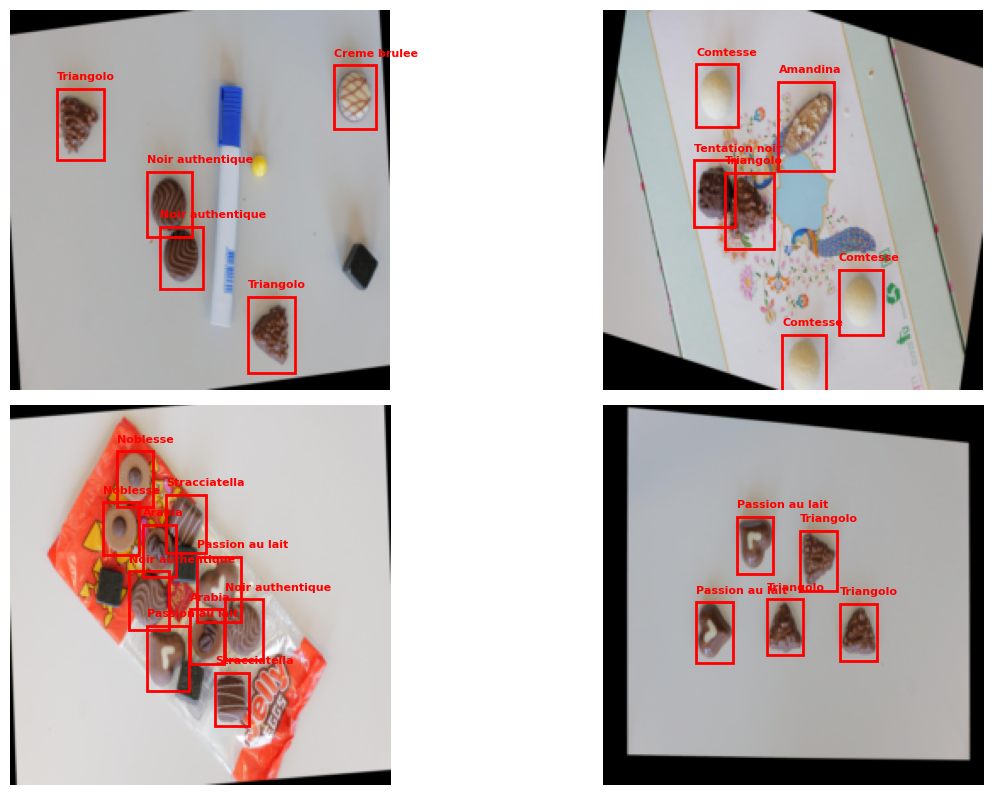

In [69]:
plot_images_from_dataset(*next(iter(augmented_train_loader)))

In [70]:
torch.manual_seed(42)

model = Net()
model.freeze_feature_layers()

learning_rate = 0.0001

criterion = nn.CrossEntropyLoss()
metrics = {'ACC': acc, 'F1-weighted': f1}
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

N_EPOCHS =  1
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
criterion.to(device)

train_cycle(model, optimizer, augmented_train_loader, val_dataloader, N_EPOCHS, device)

# save model weights
results_models_dir = 'models/'
if not os.path.exists(results_models_dir):
    os.mkdir(results_models_dir)
torch.save(model.state_dict(), results_models_dir + 'base_model_trained_on_augmented_set.pth')

c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sophi\.conda\envs\iapr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Epoch 1/1


  0%|          | 0/21 [00:00<?, ?it/s]

Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>


  5%|▍         | 1/21 [00:07<02:24,  7.22s/it]

...

Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>
Image is: <class 'module'>


Evaluating:  83%|████████▎ | 5/6 [00:15<00:03,  3.20s/it]

Image is: <class 'module'>


Evaluating: 100%|██████████| 6/6 [00:16<00:00,  2.77s/it]

Evaluated 21 images.
Train Loss: 1.6377 | Val Loss: 0.0000


In [22]:
output_submission_path = 'C:/Users/sophi/image/iapr2025/project/prediction/aug_submission.csv'
# predict_and_create_submission(model, sample_submission_path, output_submission_path)
predict_and_create_submission(
    sample_submission_path,
    output_submission_path,
    model_weights_path='C:/Users/sophi/image/iapr2025/project/models/base_model_trained_on_augmented_set.pth',
    classes=classes,  # List of class names
    device=device,
    transform=augmented_transform_train,  # Your preprocessing pipeline
    TEST_IMAGE_DIR=TEST_IMAGE_DIR
)

Submission saved to C:/Users/sophi/image/iapr2025/project/prediction/aug_submission.csv
